<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_Multivariate_Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Upload Dataset
from google.colab import files
uploaded = files.upload()

Saving energy_from2012-2014.csv to energy_from2012-2014.csv


In [2]:
# Importing the Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
# Loading the Dataset
df = pd.read_csv("energy_from2012-2014.csv")

# Displaying the first few rows
df.head()

,Unnamed: 0,load,temp
0,2012-01-01 00:00:00,2026.557043,20.221981
1,2012-01-01 01:00:00,2072.453834,22.588392
2,2012-01-01 02:00:00,2184.105763,20.710773
3,2012-01-01 03:00:00,2290.004863,24.139484
4,2012-01-01 04:00:00,2249.821288,24.560680


In [10]:
# Inspecting the dataset
df.info()

# Dataset has datetime index
# Keeping only required columns
df = df[['load','temp']]

df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26304 entries, 2012-01-01 00:00:00 to 2014-12-31 23:00:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   load    26304 non-null  float64
 1   temp    26304 non-null  float64
dtypes: float64(2)
memory usage: 616.5 KB


,load,temp
datetime,,
2012-01-01 00:00:00,2026.557043,20.221981
2012-01-01 01:00:00,2072.453834,22.588392
2012-01-01 02:00:00,2184.105763,20.710773
2012-01-01 03:00:00,2290.004863,24.139484
2012-01-01 04:00:00,2249.821288,24.560680


In [13]:
# Verifying the index
print(type(df.index))
df.index[:5]

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


DatetimeIndex(['2012-01-01 00:00:00', '2012-01-01 01:00:00',
               '2012-01-01 02:00:00', '2012-01-01 03:00:00',
               '2012-01-01 04:00:00'],
              dtype='datetime64[ns]', name='datetime', freq=None)

In [14]:
train_data = df.loc[:'2014-08-31']
valid_data = df.loc['2014-09-01':'2014-10-31']
test_data  = df.loc['2014-11-01':]

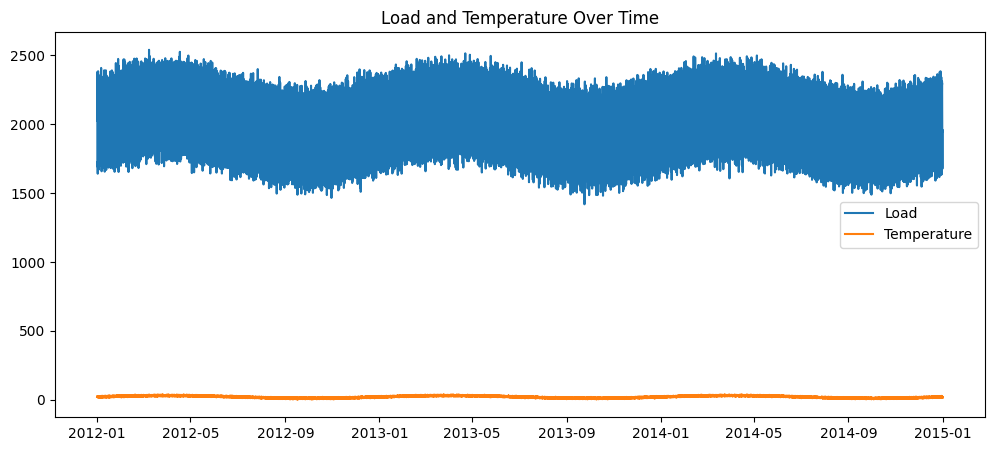

In [15]:
# Visualize the Data
plt.figure(figsize=(12,5))
plt.plot(df['load'], label='Load')
plt.plot(df['temp'], label='Temperature')
plt.legend()
plt.title("Load and Temperature Over Time")
plt.show()

In [16]:
# Splitting the Dataset
# Train, validation and test splits
train_data = df.loc[:'2014-08-31']
valid_data = df.loc['2014-09-01':'2014-10-31']
test_data  = df.loc['2014-11-01':]

print("Train shape:", train_data.shape)
print("Validation shape:", valid_data.shape)
print("Test shape:", test_data.shape)

Train shape: (23376, 2)
Validation shape: (1464, 2)
Test shape: (1464, 2)


In [18]:
# Scaling the Features
# Scaling load and temp using MinMaxScaler
scaler = MinMaxScaler()

# Fitting only on training data
scaler.fit(train_data)

# Transform all sets
train_scaled = scaler.transform(train_data)
valid_scaled = scaler.transform(valid_data)
test_scaled  = scaler.transform(test_data)

train_scaled = pd.DataFrame(train_scaled, columns=['load','temp'], index=train_data.index)
valid_scaled = pd.DataFrame(valid_scaled, columns=['load','temp'], index=valid_data.index)
test_scaled  = pd.DataFrame(test_scaled, columns=['load','temp'], index=test_data.index)

train_scaled.head()

,load,temp
datetime,,
2012-01-01 00:00:00,0.541186,0.521547
2012-01-01 01:00:00,0.582078,0.580331
2012-01-01 02:00:00,0.681554,0.533689
2012-01-01 03:00:00,0.775904,0.618861
2012-01-01 04:00:00,0.740103,0.629324


In [19]:
# Creating Lagged Features
T = 6
HORIZON = 1

def create_sequences(data, T, horizon=1):

    X = []
    y = []

    for i in range(len(data) - T - horizon + 1):

        X.append(data.iloc[i:i+T].values)
        y.append(data.iloc[i+T:i+T+horizon]['load'].values)

    return np.array(X), np.array(y)

In [20]:
# Generate Training, Validation and Test Sequences
X_train, y_train = create_sequences(train_scaled, T, HORIZON)
X_valid, y_valid = create_sequences(valid_scaled, T, HORIZON)
X_test,  y_test  = create_sequences(test_scaled,  T, HORIZON)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (23370, 6, 2)
y_train shape: (23370, 1)


In [21]:
# Building GRU Model
model = Sequential()

model.add(GRU(units=5, input_shape=(T,2)))
model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 5)              │           135 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Compiling Model
model.compile(
    optimizer='RMSprop',
    loss='mse'
)

In [23]:
# Train the Model
# Using EarlyStopping to stop from overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stop]
)

Epoch 1/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0177 - val_loss: 0.0049
Epoch 2/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 3/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0044 - val_loss: 0.0036
Epoch 4/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0041 - val_loss: 0.0033
Epoch 5/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0038 - val_loss: 0.0030
Epoch 6/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0036 - val_loss: 0.0030
Epoch 7/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0035 - val_loss: 0.0029
Epoch 8/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0035 - val_loss: 0.0034
Epoch 9/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0034 - val_loss: 0.0030
Epoch 10/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0034 - val_loss: 0.0031
Epoch 11/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0033 - val_loss: 0.0028
Epoch 12/20
731/731 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step

In [24]:
# Evaluate on Test Set
test_loss = model.evaluate(X_test, y_test)

print("Test MSE:", test_loss)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030
Test MSE: 0.003079055342823267


In [25]:
# Making Predictions
predictions = model.predict(X_test)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [26]:
# Calculainge MAPE
mape = mean_absolute_percentage_error(y_test, predictions)

print("MAPE:", mape)
print("MAPE (%):", mape*100)

MAPE: 0.11498632868779265
MAPE (%): 11.498632868779266


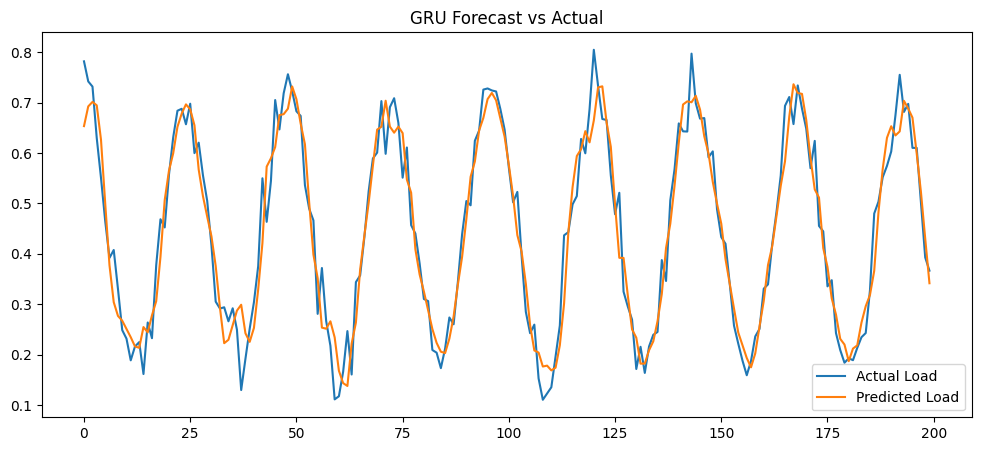

In [27]:
# Plotting Predictions vs Actual
plt.figure(figsize=(12,5))

plt.plot(y_test[:200], label="Actual Load")
plt.plot(predictions[:200], label="Predicted Load")

plt.legend()
plt.title("GRU Forecast vs Actual")
plt.show()

Summary: -
Model Performance
•	The GRU model learns temporal patterns from historical load and temperature data.
•	Using 6 hours of past information improves forecasting accuracy.
•	EarlyStopping prevents overfitting by stopping training when validation loss stops improving.
Forecasting Accuracy
•	The model achieved a low MSE and reasonable MAPE, indicating accurate predictions.
•	Temperature acts as an important explanatory variable for load demand.
Conclusion
•	Multivariate time series forecasting using GRU is effective for energy demand prediction.
•	Including multiple features improves forecasting performance compared to univariate models.
